In [1]:
import os
print(os.getcwd())

C:\Users\jnlea\Desktop\agri_vision_project


In [1]:
!pip install scikit-learn

In [2]:
import sklearn
print(sklearn.__version__)

1.8.0


In [10]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Try loading XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False

print("Setup complete.")
print("XGBoost available?", xgb_available)

Setup complete.
XGBoost available? True


In [11]:
# Confirm current working directory
print("Current working directory:")
print(os.getcwd())

# Load merged climate + yield dataset
final_df = pd.read_csv(
    "C:/Users/jnlea/Desktop/agri_vision_project/data/processed/corn_yield_climate_2020_2022.csv"
)

print("\nDataset loaded successfully.")
print("Shape:", final_df.shape)
display(final_df.head())

Current working directory:
C:\Users\jnlea\Desktop\agri_vision_project\notebooks

Dataset loaded successfully.
Shape: (0, 8)


,fips,year,state_alpha,state_name,county_name,yield_bu_per_acre,growing_precip,growing_temp


In [8]:
print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])
print(final_df.columns)

Rows: 0
Columns: 8
Index(['fips', 'year', 'state_alpha', 'state_name', 'county_name',
       'yield_bu_per_acre', 'growing_precip', 'growing_temp'],
      dtype='object')


In [12]:
# Create engineered features
final_df["temp_precip_interaction"] = final_df["growing_temp"] * final_df["growing_precip"]
final_df["heat_stress_index"] = final_df["growing_temp"] ** 2

feature_cols = [
    "growing_temp",
    "growing_precip",
    "temp_precip_interaction",
    "heat_stress_index"
]

print("Feature engineering complete.")
display(final_df[feature_cols + ["yield_bu_per_acre"]].head())

Feature engineering complete.


,growing_temp,growing_precip,temp_precip_interaction,heat_stress_index,yield_bu_per_acre


In [13]:
# Train on 2020-2021, test on 2022
train = final_df[final_df["year"] < 2022].copy()
test = final_df[final_df["year"] == 2022].copy()

X_train = train[feature_cols]
y_train = train["yield_bu_per_acre"]

X_test = test[feature_cols]
y_test = test["yield_bu_per_acre"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train years:", sorted(train["year"].unique()))
print("Test years:", sorted(test["year"].unique()))

Train shape: (0, 4)
Test shape: (0, 4)
Train years: []
Test years: []


In [14]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 3)
    }

In [17]:
print(final_df["year"].dtype)
print(final_df["year"].unique())
print(final_df["year"].value_counts().sort_index())

object
[]
Series([], Name: count, dtype: int64)


In [18]:
train = final_df[final_df["year"] < 2022].copy()
test = final_df[final_df["year"] == 2022].copy()

print("Train rows:", len(train))
print("Test rows:", len(test))

print("Train years:", train["year"].unique())
print("Test years:", test["year"].unique())

Train rows: 0
Test rows: 0
Train years: []
Test years: []


In [21]:
import os
import pandas as pd

file_path = (
    "C:/Users/jnlea/Desktop/agri_vision_project/data/processed/corn_yield_climate_2020_2022.csv"
)

print("File exists:", os.path.exists(file_path))
print("File size (bytes):", os.path.getsize(file_path))

raw_check = pd.read_csv(file_path)
print("Loaded shape:", raw_check.shape)
display(raw_check.head())
print(raw_check.columns.tolist())

File exists: True
File size (bytes): 92
Loaded shape: (0, 8)


,fips,year,state_alpha,state_name,county_name,yield_bu_per_acre,growing_precip,growing_temp


['fips', 'year', 'state_alpha', 'state_name', 'county_name', 'yield_bu_per_acre', 'growing_precip', 'growing_temp']


In [23]:
train = final_df[final_df["year"] < 2022].copy()
test = final_df[final_df["year"] == 2022].copy()

print("Train rows:", len(train))
print("Test rows:", len(test))

print("Train years:", train["year"].unique())
print("Test years:", test["year"].unique())

Train rows: 0
Test rows: 0
Train years: []
Test years: []


In [33]:
import pandas as pd

# Correct path to raw files
raw_path = "C:/Users/jnlea/Desktop/agri_vision_project/data/raw/"

# column names
cols = ["id"] + list(range(1,13))

# load climate data
pcp = pd.read_csv(raw_path + "pcpncy.txt", delim_whitespace=True, header=None, names=cols)
tmax = pd.read_csv(raw_path + "tmaxcy.txt", delim_whitespace=True, header=None, names=cols)
tmin = pd.read_csv(raw_path + "tmincy.txt", delim_whitespace=True, header=None, names=cols)

print("Loaded shapes:")
print("PCP:", pcp.shape)
print("TMAX:", tmax.shape)
print("TMIN:", tmin.shape)

pcp.head()

Loaded shapes:
PCP: (413364, 13)
TMAX: (413364, 13)
TMIN: (413364, 13)


,id,1,2,3,4,5,6,7,8,9,10,11,12
0,1001011895,7.03,2.96,8.36,3.53,3.96,5.40,3.92,3.36,0.73,2.03,1.44,3.66
1,1001011896,5.86,5.42,5.54,3.98,3.77,6.24,4.38,2.57,0.82,1.66,2.89,1.94
2,1001011897,3.27,6.63,10.94,4.35,0.81,1.57,3.96,5.02,0.87,0.75,1.84,4.38
3,1001011898,2.33,2.07,2.60,4.56,0.54,3.13,5.80,6.02,1.51,3.21,6.66,3.91
4,1001011899,5.80,6.94,3.35,2.22,2.93,2.31,6.80,2.90,0.63,3.02,1.98,5.25


In [34]:
def extract_fips_year(df):
    s = df["id"].astype(str).str.strip()

    df["fips"] = s.str[:5]
    df["year"] = s.str[-4:].astype(int)

    df = df.drop(columns=["id"])
    return df

In [35]:
pcp = extract_fips_year(pcp)
tmax = extract_fips_year(tmax)
tmin = extract_fips_year(tmin)

print(pcp[["fips", "year"]].head())

    fips  year
0  10010  1895
1  10010  1896
2  10010  1897
3  10010  1898
4  10010  1899


In [36]:
pcp = pcp[pcp["year"].between(2020, 2022)]
tmax = tmax[tmax["year"].between(2020, 2022)]
tmin = tmin[tmin["year"].between(2020, 2022)]

print("PCP:", pcp.shape)
print("TMAX:", tmax.shape)
print("TMIN:", tmin.shape)
print(pcp["year"].value_counts().sort_index())

PCP: (9426, 14)
TMAX: (9426, 14)
TMIN: (9426, 14)
year
2020    3142
2021    3142
2022    3142
Name: count, dtype: int64


In [37]:
print("PCP:", pcp.shape)
print(pcp["year"].value_counts().sort_index())

PCP: (9426, 14)
year
2020    3142
2021    3142
2022    3142
Name: count, dtype: int64


In [38]:
growing_months = [4, 5, 6, 7, 8, 9]

# Growing-season precipitation = sum of Apr-Sep
pcp["growing_precip"] = pcp[growing_months].sum(axis=1)

# Growing-season average temperature = average of Apr-Sep mean temp
tavg_monthly = (tmax[growing_months] + tmin[growing_months]) / 2
tmax["growing_temp"] = tavg_monthly.mean(axis=1)

# Final climate feature table
climate = pcp[["fips", "year", "growing_precip"]].merge(
    tmax[["fips", "year", "growing_temp"]],
    on=["fips", "year"],
    how="inner"
)

print("Climate shape:", climate.shape)
display(climate.head())

Climate shape: (7905, 4)


,fips,year,growing_precip,growing_temp
0,50050,2020,6.50,47.966667
1,50050,2021,10.46,45.491667
2,50050,2022,7.66,47.150000
3,50070,2020,5.54,48.575000
4,50070,2021,9.63,45.875000


In [39]:
yield_df = pd.read_csv(
    "C:/Users/jnlea/Desktop/agri_vision_project/data/processed/usda_corn_yield_county_2020_2022.csv"
)

print("Yield shape:", yield_df.shape)
display(yield_df.head())
print(yield_df.columns.tolist())

Yield shape: (2442, 6)


,fips,year,state_alpha,state_name,county_name,yield_bu_per_acre
0,17001,2020,IL,ILLINOIS,ADAMS,177.5
1,17003,2020,IL,ILLINOIS,ALEXANDER,181.7
2,17005,2020,IL,ILLINOIS,BOND,185.6
3,17007,2020,IL,ILLINOIS,BOONE,192.2
4,17009,2020,IL,ILLINOIS,BROWN,181.3


['fips', 'year', 'state_alpha', 'state_name', 'county_name', 'yield_bu_per_acre']


In [40]:
yield_df["fips"] = yield_df["fips"].astype(str).str.zfill(5)
yield_df["year"] = pd.to_numeric(yield_df["year"], errors="coerce")

climate["fips"] = climate["fips"].astype(str).str.zfill(5)
climate["year"] = pd.to_numeric(climate["year"], errors="coerce")

print("Yield years:", sorted(yield_df["year"].dropna().unique()))
print("Climate years:", sorted(climate["year"].dropna().unique()))

Yield years: [2020, 2021, 2022]
Climate years: [2020, 2021, 2022]


In [41]:
common_fips = set(yield_df["fips"]).intersection(set(climate["fips"]))
common_years = set(yield_df["year"]).intersection(set(climate["year"]))

print("Common FIPS count:", len(common_fips))
print("Common years:", common_years)

Common FIPS count: 411
Common years: {2020, 2021, 2022}


In [42]:
final_df = yield_df.merge(
    climate,
    on=["fips", "year"],
    how="inner"
)

print("Final merged shape:", final_df.shape)
display(final_df.head())

Final merged shape: (1060, 8)


,fips,year,state_alpha,state_name,county_name,yield_bu_per_acre,growing_precip,growing_temp
0,17001,2020,IL,ILLINOIS,ADAMS,177.5,20.70,59.716667
1,17003,2020,IL,ILLINOIS,ALEXANDER,181.7,13.71,55.633333
2,17005,2020,IL,ILLINOIS,BOND,185.6,20.11,60.400000
3,17007,2020,IL,ILLINOIS,BOONE,192.2,19.47,55.050000
4,17009,2020,IL,ILLINOIS,BROWN,181.3,17.57,58.883333


In [43]:
final_df.to_csv(
    "C:/Users/jnlea/Desktop/agri_vision_project/data/processed/corn_yield_climate_2020_2022.csv",
    index=False
)

print("Saved corrected merged dataset.")

Saved corrected merged dataset.


In [44]:
# Feature engineering
final_df["temp_precip_interaction"] = final_df["growing_temp"] * final_df["growing_precip"]
final_df["heat_stress_index"] = final_df["growing_temp"] ** 2

feature_cols = [
    "growing_temp",
    "growing_precip",
    "temp_precip_interaction",
    "heat_stress_index"
]

from sklearn.model_selection import train_test_split

X = final_df[feature_cols]
y = final_df["yield_bu_per_acre"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (848, 4)
Test: (212, 4)


In [45]:
print("Climate shape:", climate.shape)
print("Yield shape:", yield_df.shape)
print("Final merged shape:", final_df.shape)

Climate shape: (7905, 4)
Yield shape: (2442, 6)
Final merged shape: (1060, 10)


In [46]:
# Feature engineering
final_df["temp_precip_interaction"] = final_df["growing_temp"] * final_df["growing_precip"]
final_df["heat_stress_index"] = final_df["growing_temp"] ** 2

feature_cols = [
    "growing_temp",
    "growing_precip",
    "temp_precip_interaction",
    "heat_stress_index"
]

from sklearn.model_selection import train_test_split

X = final_df[feature_cols]
y = final_df["yield_bu_per_acre"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (848, 4)
Test: (212, 4)


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "R2": round(r2_score(y_true, y_pred), 3)
    }

In [48]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X_train, y_train)

pred_lin = lin.predict(X_test)
lin_results = evaluate_model("Linear Regression", y_test, pred_lin)

print(lin_results)

{'Model': 'Linear Regression', 'MAE': 31.45, 'RMSE': 39.52, 'R2': 0.051}


In [49]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
rf_results = evaluate_model("Random Forest", y_test, pred_rf)

print(rf_results)

{'Model': 'Random Forest', 'MAE': 31.9, 'RMSE': 40.02, 'R2': 0.027}


In [50]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
xgb_results = evaluate_model("XGBoost", y_test, pred_xgb)

print(xgb_results)

{'Model': 'XGBoost', 'MAE': 30.21, 'RMSE': 38.42, 'R2': 0.103}


In [51]:
import pandas as pd

results_df = pd.DataFrame([lin_results, rf_results, xgb_results]).sort_values("RMSE")
results_df

,Model,MAE,RMSE,R2
2,XGBoost,30.21,38.42,0.103
0,Linear Regression,31.45,39.52,0.051
1,Random Forest,31.90,40.02,0.027


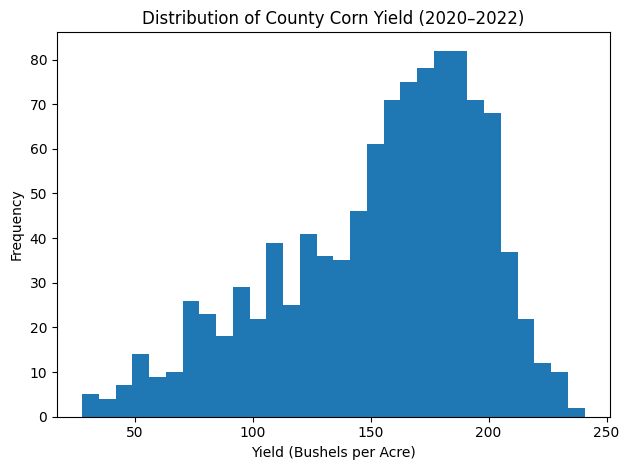

In [54]:
import os
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)

plt.figure()
plt.hist(final_df["yield_bu_per_acre"], bins=30)
plt.title("Distribution of County Corn Yield (2020–2022)")
plt.xlabel("Yield (Bushels per Acre)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../figures/figure1_yield_distribution.png", dpi=300)
plt.show()

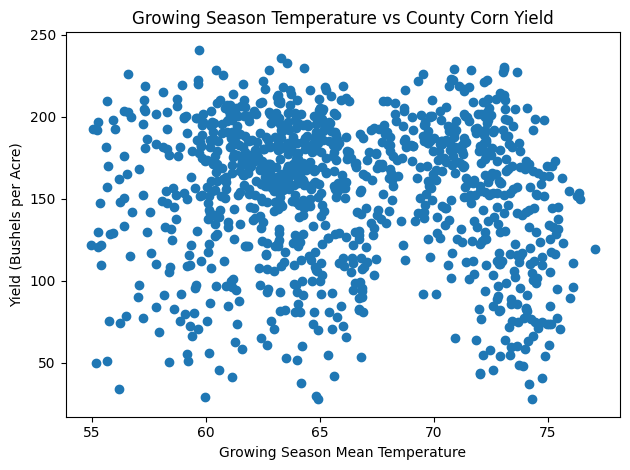

In [55]:
plt.figure()
plt.scatter(final_df["growing_temp"], final_df["yield_bu_per_acre"])
plt.title("Growing Season Temperature vs County Corn Yield")
plt.xlabel("Growing Season Mean Temperature")
plt.ylabel("Yield (Bushels per Acre)")
plt.tight_layout()
plt.savefig("../figures/figure2_temp_vs_yield.png", dpi=300)
plt.show()

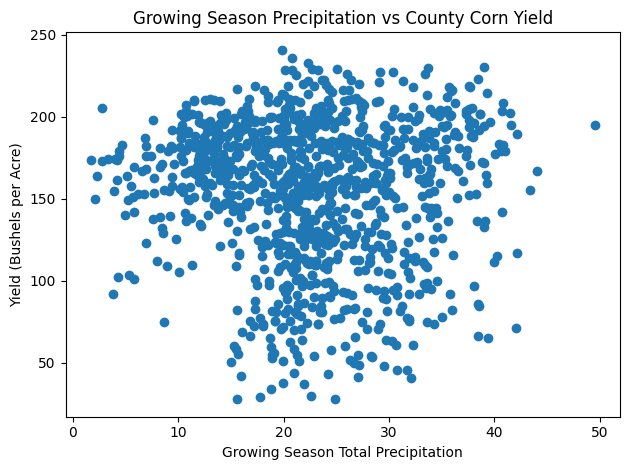

In [56]:
plt.figure()
plt.scatter(final_df["growing_precip"], final_df["yield_bu_per_acre"])
plt.title("Growing Season Precipitation vs County Corn Yield")
plt.xlabel("Growing Season Total Precipitation")
plt.ylabel("Yield (Bushels per Acre)")
plt.tight_layout()
plt.savefig("../figures/figure3_precip_vs_yield.png", dpi=300)
plt.show()

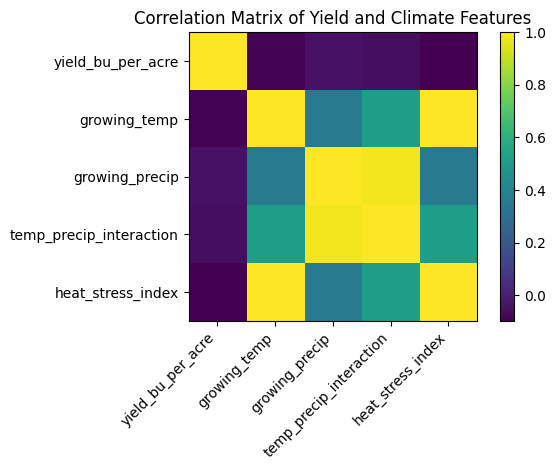

In [57]:
corr = final_df[
    ["yield_bu_per_acre", "growing_temp", "growing_precip",
     "temp_precip_interaction", "heat_stress_index"]
].corr()

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Yield and Climate Features")
plt.colorbar()
plt.tight_layout()
plt.savefig("../figures/figure4_correlation_matrix.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

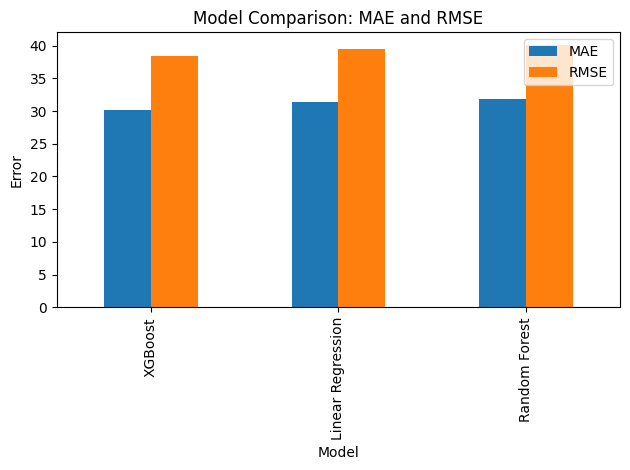

In [58]:
plot_df = results_df.set_index("Model")[["MAE", "RMSE"]]

plt.figure()
plot_df.plot(kind="bar")
plt.title("Model Comparison: MAE and RMSE")
plt.xlabel("Model")
plt.ylabel("Error")
plt.tight_layout()
plt.savefig("../figures/figure5_model_comparison.png", dpi=300)
plt.show()

In [59]:
results_df = pd.DataFrame([lin_results, rf_results, xgb_results]).sort_values("RMSE")
results_df

,Model,MAE,RMSE,R2
2,XGBoost,30.21,38.42,0.103
0,Linear Regression,31.45,39.52,0.051
1,Random Forest,31.90,40.02,0.027
